In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

try:
    df = pd.read_csv('data_transaction.csv')
    print(" Dataset 'data_transaction.csv' berhasil dimuat dan 'df' didefinisikan.")
except FileNotFoundError:
    print(" ERROR: File 'data_transaction.csv' tidak ditemukan. Pastikan nama file dan direktori sudah benar.")
    exit()

print("\n" + "=" * 50)
print("## 2.1. Informasi Dataset Awal")
print("=" * 50)
df.info()

print("\n" + "=" * 50)
print("## 2.2. Lima Baris Pertama")
print("=" * 50)
display(df.head(5))

print("\n" + "=" * 50)
print("## 3.1. Konversi Tipe Data Tanggal")
print("=" * 50)

date_cols = ['issue_d', 'earliest_cr_line']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format='%b-%Y')
    
print(f"Kolom {date_cols} berhasil dikonversi ke tipe data datetime.")

print("\n" + "=" * 50)
print("## 3.2. Pembersihan dan Konversi 'emp_length'")
print("=" * 50)

def clean_emp_length(length):
    if pd.isna(length):
        return length 
    return str(length).replace(' years', '').replace(' year', '').replace('+', '').replace('< 1', '0')

df['emp_length'] = df['emp_length'].apply(clean_emp_length)
df['emp_length'] = pd.to_numeric(df['emp_length'], errors='coerce')

print(f"Kolom 'emp_length' berhasil dibersihkan dan diubah ke numerik.")

missing_percent = (df.isnull().sum() / len(df)) * 100
missing_info = pd.DataFrame({'Percent Missing': missing_percent.round(2)}).sort_values(by='Percent Missing', ascending=False)
print("\n" + "=" * 50)
print("## 4.1. Nilai Hilang Sebelum Imputasi/Penghapusan")
print("=" * 50)
display(missing_info[missing_info['Percent Missing'] > 0])

df = df.drop(['emp_title', 'title'], axis=1)
print("\n-> Kolom 'emp_title' dan 'title' (Jabatan Kerja dan Judul Pinjaman) **dihapus**.")

df['mort_acc'] = df['mort_acc'].fillna(0)
print("-> Nilai hilang di 'mort_acc' diisi dengan **0**.")

median_emp_length = df['emp_length'].median()
df['emp_length'] = df['emp_length'].fillna(median_emp_length)
print(f"-> Nilai hilang di 'emp_length' diisi dengan **Median ({median_emp_length:.0f})**.")

median_revol_util = df['revol_util'].median()
df['revol_util'] = df['revol_util'].fillna(median_revol_util)
print(f"-> Nilai hilang di 'revol_util' diisi dengan **Median ({median_revol_util:.2f})**.")

mode_bankruptcies = df['pub_rec_bankruptcies'].mode()[0]
df['pub_rec_bankruptcies'] = df['pub_rec_bankruptcies'].fillna(mode_bankruptcies)
print(f"-> Nilai hilang di 'pub_rec_bankruptcies' diisi dengan **Mode ({mode_bankruptcies:.0f})**.")

print("\n" + "=" * 50)
print("## 5.1. Verifikasi Akhir Nilai Hilang")
print("=" * 50)
final_missing = (df.isnull().sum() / len(df)) * 100
final_missing_info = pd.DataFrame({'Percent Missing': final_missing.round(4)})
display(final_missing_info[final_missing_info['Percent Missing'] > 0])

print("\n Pembersihan Data Selesai! Dataset siap untuk Analisis Univariat/Bivariat.")
print(f"Jumlah kolom sekarang: {df.shape[1]}")

 Dataset 'data_transaction.csv' berhasil dimuat dan 'df' didefinisikan.

## 2.1. Informasi Dataset Awal
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.00,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.00,Not Verified,Jan-2015,Fully Paid,vacation,Vacation,26.24,Jun-1990,16.00,0.00,36369.00,41.80,25.00,w,INDIVIDUAL,0.00,0.00,"0174 Michelle Gateway\nMendozaberg, OK 22690"
1,8000.00,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.00,Not Verified,Jan-2015,Fully Paid,debt_consolidation,Debt consolidation,22.05,Jul-2004,17.00,0.00,20131.00,53.30,27.00,f,INDIVIDUAL,3.00,0.00,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113"
2,15600.00,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.00,Source Verified,Jan-2015,Fully Paid,credit_card,Credit card refinancing,12.79,Aug-2007,13.00,0.00,11987.00,92.20,26.00,f,INDIVIDUAL,0.00,0.00,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113"
3,7200.00,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.00,Not Verified,Nov-2014,Fully Paid,credit_card,Credit card refinancing,2.60,Sep-2006,6.00,0.00,5472.00,21.50,13.00,f,INDIVIDUAL,0.00,0.00,"823 Reid Ford\nDelacruzside, MA 00813"
4,24375.00,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.00,Verified,Apr-2013,Charged Off,credit_card,Credit Card Refinance,33.95,Mar-1999,13.00,0.00,24584.00,69.80,43.00,f,INDIVIDUAL,1.00,0.00,"679 Luna Roads\nGreggshire, VA 11650"



## 3.1. Konversi Tipe Data Tanggal
Kolom ['issue_d', 'earliest_cr_line'] berhasil dikonversi ke tipe data datetime.

## 3.2. Pembersihan dan Konversi 'emp_length'
Kolom 'emp_length' berhasil dibersihkan dan diubah ke numerik.

## 4.1. Nilai Hilang Sebelum Imputasi/Penghapusan


,Percent Missing
mort_acc,9.54
emp_title,5.79
emp_length,4.62
title,0.44
pub_rec_bankruptcies,0.14
revol_util,0.07



-> Kolom 'emp_title' dan 'title' (Jabatan Kerja dan Judul Pinjaman) **dihapus**.
-> Nilai hilang di 'mort_acc' diisi dengan **0**.
-> Nilai hilang di 'emp_length' diisi dengan **Median (6)**.
-> Nilai hilang di 'revol_util' diisi dengan **Median (54.80)**.
-> Nilai hilang di 'pub_rec_bankruptcies' diisi dengan **Mode (0)**.

## 5.1. Verifikasi Akhir Nilai Hilang


,Percent Missing



 Pembersihan Data Selesai! Dataset siap untuk Analisis Univariat/Bivariat.
Jumlah kolom sekarang: 25


## 5.1. Distribusi Variabel Target: loan_status
Jumlah masing-masing status pinjaman:
loan_status
Fully Paid     318357
Charged Off     77673
Name: count, dtype: int64
--------------------------------------------------
Persentase masing-masing status pinjaman:
loan_status
Fully Paid    80.39
Charged Off   19.61
Name: proportion, dtype: float64

## 5.2. Analisis Kategori Pinjaman Final (Fully Paid vs. Charged Off)
Jumlah baris setelah filter (Status Final): 396030
Proporsi Pinjaman Final:
loan_status
Fully Paid    80.39
Charged Off   19.61
Name: proportion, dtype: float64
--------------------------------------------------


/tmp/ipykernel_9597/3699469033.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=df_final, palette='viridis')


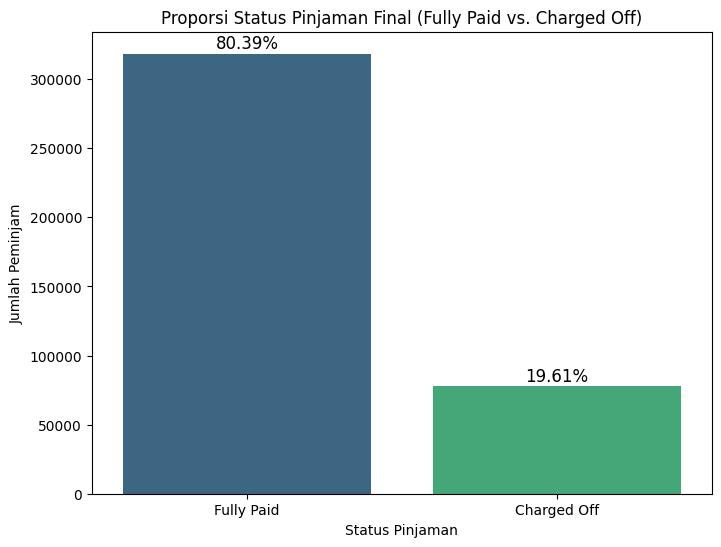

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("=" * 50)
print("## 5.1. Distribusi Variabel Target: loan_status")
print("=" * 50)

status_counts = df['loan_status'].value_counts()
print("Jumlah masing-masing status pinjaman:")
print(status_counts)
print("-" * 50)

status_percent = df['loan_status'].value_counts(normalize=True) * 100
print("Persentase masing-masing status pinjaman:")
print(status_percent.round(2))

final_statuses = ['Fully Paid', 'Charged Off']
df_final = df[df['loan_status'].isin(final_statuses)]

print("\n" + "=" * 50)
print("## 5.2. Analisis Kategori Pinjaman Final (Fully Paid vs. Charged Off)")
print("=" * 50)

final_status_counts = df_final['loan_status'].value_counts()
final_status_percent = df_final['loan_status'].value_counts(normalize=True) * 100

print(f"Jumlah baris setelah filter (Status Final): {len(df_final)}")
print("Proporsi Pinjaman Final:")
print(final_status_percent.round(2))
print("-" * 50)

plt.figure(figsize=(8, 6))
sns.countplot(x='loan_status', data=df_final, palette='viridis')
plt.title('Proporsi Status Pinjaman Final (Fully Paid vs. Charged Off)')
plt.xlabel('Status Pinjaman')
plt.ylabel('Jumlah Peminjam')
for i, count in enumerate(final_status_counts):
    percentage = f'{final_status_percent.iloc[i]:.2f}%'
    plt.text(i, count + 1000, percentage, ha='center', va='bottom', fontsize=12)
plt.show()

## 6.1. Statistik Suku Bunga Berdasarkan Status Pinjaman
Statistik Suku Bunga (int_rate):


,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,77673.00,15.88,4.39,5.32,12.99,15.61,18.64,30.99
Fully Paid,318357.00,13.09,4.32,5.32,9.91,12.99,15.61,30.99


--------------------------------------------------


/tmp/ipykernel_9597/3064348645.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_status', y='int_rate', data=df_final, palette='Set1')


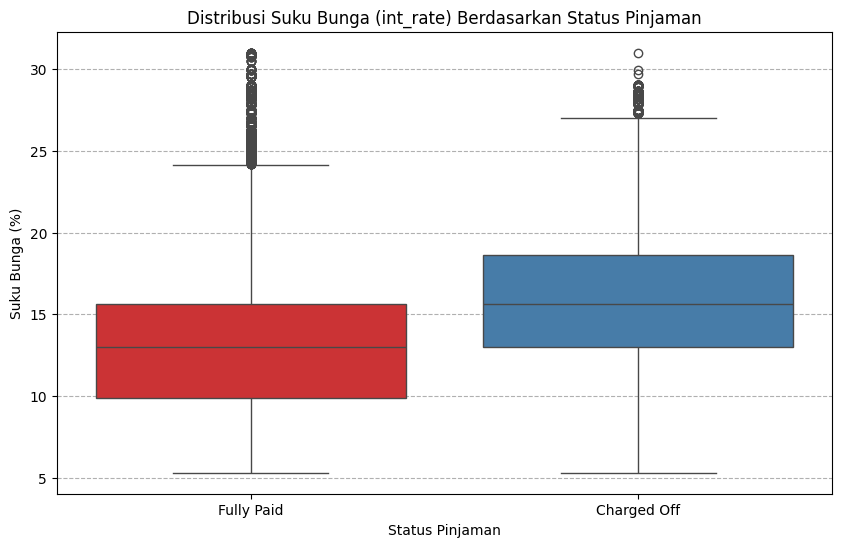

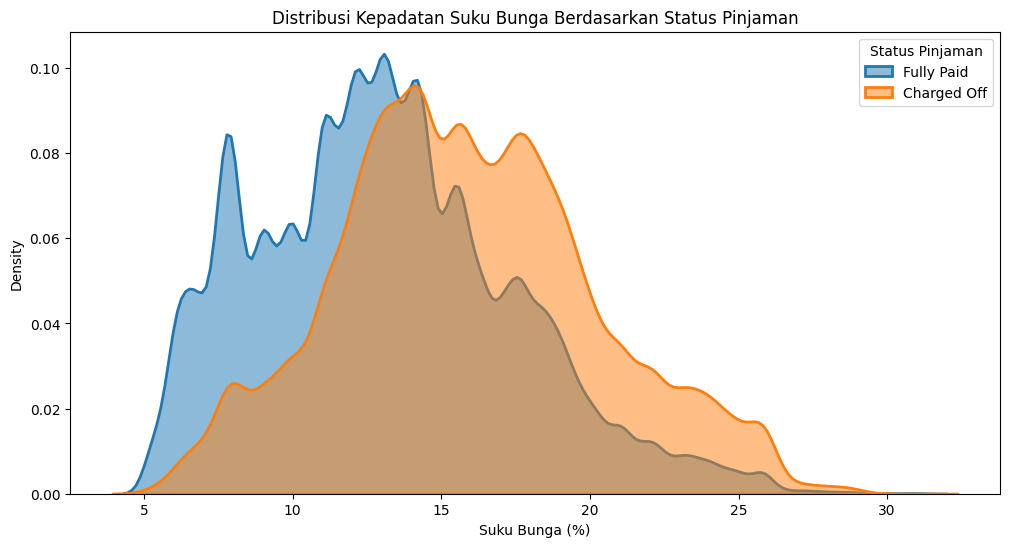

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

final_statuses = ['Fully Paid', 'Charged Off']
df_final = df[df['loan_status'].isin(final_statuses)].copy() 

print("=" * 50)
print("## 6.1. Statistik Suku Bunga Berdasarkan Status Pinjaman")
print("=" * 50)

int_rate_analysis = df_final.groupby('loan_status')['int_rate'].describe()
print("Statistik Suku Bunga (int_rate):")
display(int_rate_analysis)
print("-" * 50)

plt.figure(figsize=(10, 6))
sns.boxplot(x='loan_status', y='int_rate', data=df_final, palette='Set1')
plt.title('Distribusi Suku Bunga (int_rate) Berdasarkan Status Pinjaman')
plt.xlabel('Status Pinjaman')
plt.ylabel('Suku Bunga (%)')
plt.grid(axis='y', linestyle='--')
plt.show()

plt.figure(figsize=(12, 6))
sns.kdeplot(df_final[df_final['loan_status'] == 'Fully Paid']['int_rate'], 
            label='Fully Paid', fill=True, alpha=0.5, linewidth=2)
sns.kdeplot(df_final[df_final['loan_status'] == 'Charged Off']['int_rate'], 
            label='Charged Off', fill=True, alpha=0.5, linewidth=2)
plt.title('Distribusi Kepadatan Suku Bunga Berdasarkan Status Pinjaman')
plt.xlabel('Suku Bunga (%)')
plt.legend(title='Status Pinjaman')
plt.show()

## 7.1. Tingkat Gagal Bayar (Charged Off Rate) Berdasarkan Kelas Pinjaman (Grade)
Ringkasan Jumlah Pinjaman dan Tingkat Gagal Bayar per Grade:


/tmp/ipykernel_9597/760278033.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grade_counts = df_final.groupby('grade')['loan_status'].value_counts().unstack(fill_value=0)


loan_status,Charged Off,Fully Paid,Charged Off Rate (%)
grade,,,
A,4036,60151,6.29
B,14587,101431,12.57
C,22449,83538,21.18
D,18338,45186,28.87
E,11765,19723,37.36
F,5037,6735,42.79
G,1461,1593,47.84


--------------------------------------------------


/tmp/ipykernel_9597/760278033.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


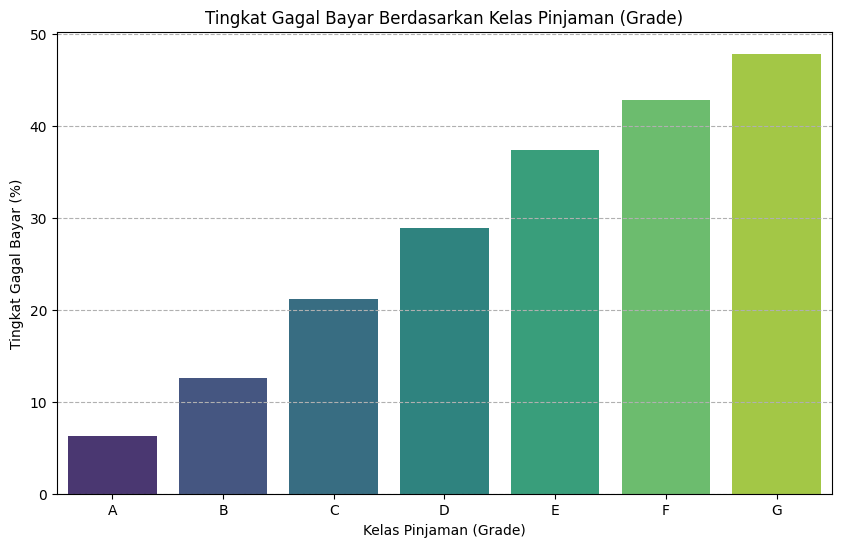

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
df_final['grade'] = pd.Categorical(df_final['grade'], categories=grade_order, ordered=True)

print("=" * 50)
print("## 7.1. Tingkat Gagal Bayar (Charged Off Rate) Berdasarkan Kelas Pinjaman (Grade)")
print("=" * 50)

grade_counts = df_final.groupby('grade')['loan_status'].value_counts().unstack(fill_value=0)

grade_counts['Charged Off Rate (%)'] = (grade_counts['Charged Off'] / (grade_counts['Charged Off'] + grade_counts['Fully Paid'])) * 100

print("Ringkasan Jumlah Pinjaman dan Tingkat Gagal Bayar per Grade:")
display(grade_counts.sort_index())
print("-" * 50)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=grade_counts.index, 
    y='Charged Off Rate (%)', 
    data=grade_counts.reset_index(), 
    palette='viridis'
)
plt.title('Tingkat Gagal Bayar Berdasarkan Kelas Pinjaman (Grade)')
plt.xlabel('Kelas Pinjaman (Grade)')
plt.ylabel('Tingkat Gagal Bayar (%)')
plt.grid(axis='y', linestyle='--')
plt.show()

## 8.1. Ekstraksi 3 Digit Kode Pos
 Kolom 'zip_code_3digit' berhasil dibuat.
 Kolom 'address' asli telah dihapus.
Jumlah kategori kode pos unik: 10
--------------------------------------------------
## 8.2. Verifikasi Hasil


,zip_code_3digit,loan_status,int_rate,grade
0,226,Fully Paid,11.44,B
1,051,Fully Paid,11.99,B
2,051,Fully Paid,10.49,B
3,008,Fully Paid,6.49,A
4,116,Charged Off,17.27,C


--------------------------------------------------
## 8.3. 10 Kode Pos 3 Digit dengan Tingkat Gagal Bayar Tertinggi


loan_status,Charged Off,Fully Paid,Total,Charged Off Rate (%)
zip_code_3digit,,,,
116,11226,0,11226,100.00
866,10981,0,10981,100.00
937,11151,0,11151,100.00
480,11192,44725,55917,20.02
704,11148,45837,56985,19.56
307,11021,45525,56546,19.49
226,10954,45573,56527,19.38
008,0,45824,45824,0.00
051,0,45402,45402,0.00


/tmp/ipykernel_9597/486620311.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


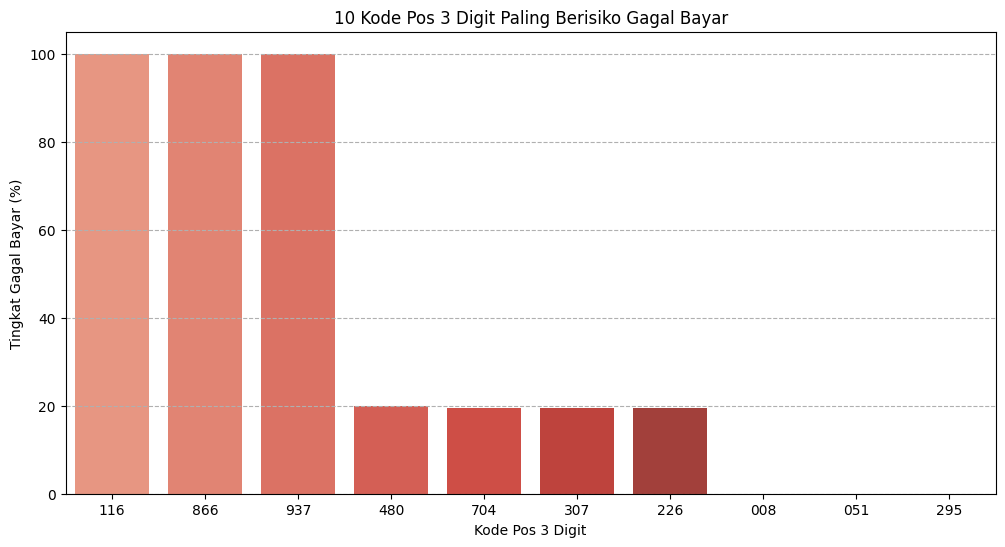

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 50)
print("## 8.1. Ekstraksi 3 Digit Kode Pos")
print("=" * 50)

def extract_zip_3digit(address):

    if pd.isna(address):
        return 'MISSING'
    five_digit_zip = address[-5:]     
    return five_digit_zip[:3]

df_final['zip_code_3digit'] = df_final['address'].apply(extract_zip_3digit)

df_final = df_final.drop('address', axis=1)

print(" Kolom 'zip_code_3digit' berhasil dibuat.")
print(" Kolom 'address' asli telah dihapus.")
print(f"Jumlah kategori kode pos unik: {df_final['zip_code_3digit'].nunique()}")
print("-" * 50)

print("## 8.2. Verifikasi Hasil")
display(df_final[['zip_code_3digit', 'loan_status', 'int_rate', 'grade']].head())
print("-" * 50)

zip_counts = df_final.groupby('zip_code_3digit')['loan_status'].value_counts().unstack(fill_value=0)
zip_counts['Total'] = zip_counts['Charged Off'] + zip_counts['Fully Paid']
zip_counts['Charged Off Rate (%)'] = (zip_counts['Charged Off'] / zip_counts['Total']) * 100

min_loans = 1000
zip_risk_analysis = zip_counts[zip_counts['Total'] > min_loans].sort_values(by='Charged Off Rate (%)', ascending=False)

print("## 8.3. 10 Kode Pos 3 Digit dengan Tingkat Gagal Bayar Tertinggi")
display(zip_risk_analysis.head(10))

plt.figure(figsize=(12, 6))
sns.barplot(
    x=zip_risk_analysis.head(10).index, 
    y='Charged Off Rate (%)', 
    data=zip_risk_analysis.head(10).reset_index(), 
    palette='Reds_d'
)
plt.title('10 Kode Pos 3 Digit Paling Berisiko Gagal Bayar')
plt.xlabel('Kode Pos 3 Digit')
plt.ylabel('Tingkat Gagal Bayar (%)')
plt.grid(axis='y', linestyle='--')
plt.show()

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

print("=" * 50)
print("## 9. Persiapan Data untuk Pemodelan Prediktif")
print("=" * 50)

categorical_cols = df_final.select_dtypes(include='object').columns.tolist()
print(f"Variabel Kategorikal yang akan di-encode: {categorical_cols}")

cols_to_encode = [
    'term', 'grade', 'home_ownership', 'verification_status',
    'purpose', 'initial_list_status', 'application_type', 'zip_code_3digit'
]

df_final = df_final.drop(['earliest_cr_line', 'issue_d', 'sub_grade'], axis=1) 
print("-> Kolom Datetime ('earliest_cr_line', 'issue_d') dan 'sub_grade' dihapus.")
print("-" * 50)

df_encoded = pd.get_dummies(df_final, columns=cols_to_encode, drop_first=True)

print(" Encoding Selesai.")
print(f"Jumlah Kolom setelah Encoding: {df_encoded.shape[1]}")
display(df_encoded.head(2))
print("-" * 50)

df_encoded['loan_status'] = df_encoded['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})

X = df_encoded.drop('loan_status', axis=1) # Fitur
y = df_encoded['loan_status']              # Target

print(" Target 'loan_status' diubah menjadi biner: 0 (Fully Paid), 1 (Charged Off).")
print(f"Bentuk X (Fitur): {X.shape}")
print(f"Bentuk y (Target): {y.shape}")
print("-" * 50)

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.30, 
    random_state=101, 
    stratify=y
)

print(" Pembagian data (Train/Test Split) Selesai.")
print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test: {X_test.shape}")
print("-" * 50)

print(" Data Anda kini siap sepenuhnya untuk digunakan dalam Pemodelan Prediktif!")

## 9. Persiapan Data untuk Pemodelan Prediktif
Variabel Kategorikal yang akan di-encode: ['term', 'sub_grade', 'home_ownership', 'verification_status', 'loan_status', 'purpose', 'initial_list_status', 'application_type', 'zip_code_3digit']
-> Kolom Datetime ('earliest_cr_line', 'issue_d') dan 'sub_grade' dihapus.
--------------------------------------------------
 Encoding Selesai.
Jumlah Kolom setelah Encoding: 53


,loan_amnt,int_rate,installment,emp_length,annual_inc,loan_status,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,term_ 60 months,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,verification_status_Source Verified,verification_status_Verified,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,initial_list_status_w,application_type_INDIVIDUAL,application_type_JOINT,zip_code_3digit_051,zip_code_3digit_116,zip_code_3digit_226,zip_code_3digit_295,zip_code_3digit_307,zip_code_3digit_480,zip_code_3digit_704,zip_code_3digit_866,zip_code_3digit_937
0,10000.00,11.44,329.48,10.00,117000.00,Fully Paid,26.24,16.00,0.00,36369.00,41.80,25.00,0.00,0.00,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,False,False,False,True,False,False,False,False,False,False
1,8000.00,11.99,265.68,4.00,65000.00,Fully Paid,22.05,17.00,0.00,20131.00,53.30,27.00,3.00,0.00,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False


--------------------------------------------------
 Target 'loan_status' diubah menjadi biner: 0 (Fully Paid), 1 (Charged Off).
Bentuk X (Fitur): (396030, 52)
Bentuk y (Target): (396030,)
--------------------------------------------------
 Pembagian data (Train/Test Split) Selesai.
Ukuran X_train: (277221, 52)
Ukuran X_test: (118809, 52)
--------------------------------------------------
 Data Anda kini siap sepenuhnya untuk digunakan dalam Pemodelan Prediktif!


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("=" * 50)
print("## 10. Pemodelan Prediktif (Regresi Logistik Dasar)")
print("=" * 50)

logmodel = LogisticRegression(solver='liblinear', random_state=101, max_iter=1000)

print("-> Melatih Model Regresi Logistik...")
logmodel.fit(X_train, y_train)

predictions = logmodel.predict(X_test)
prediction_proba = logmodel.predict_proba(X_test)[:, 1] 

print("-> Prediksi Selesai.")
print("-" * 50)

print("## 10.3. Matriks Kebingungan (Confusion Matrix)")
print(confusion_matrix(y_test, predictions))

print("\n## 10.4. Laporan Klasifikasi (Classification Report)")
print(classification_report(y_test, predictions))

auc_score = roc_auc_score(y_test, prediction_proba)
print(f"## 10.5. Skor AUC: {auc_score:.4f}")

print("-" * 50)
print(" Pemodelan Selesai. Laporan kinerja model telah ditampilkan.")

## 10. Pemodelan Prediktif (Regresi Logistik Dasar)
-> Melatih Model Regresi Logistik...
-> Prediksi Selesai.
--------------------------------------------------
## 10.3. Matriks Kebingungan (Confusion Matrix)
[[95466    41]
 [23284    18]]

## 10.4. Laporan Klasifikasi (Classification Report)
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     95507
           1       0.31      0.00      0.00     23302

    accuracy                           0.80    118809
   macro avg       0.55      0.50      0.45    118809
weighted avg       0.71      0.80      0.72    118809

## 10.5. Skor AUC: 0.5896
--------------------------------------------------
 Pemodelan Selesai. Laporan kinerja model telah ditampilkan.


In [8]:
import pandas as pd
import numpy as np

print("=" * 50)
print("## 11. Analisis Koefisien Model (Feature Importance)")
print("=" * 50)

coefficients = logmodel.coef_[0]
feature_names = X_train.columns

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df['Magnitude'] = coef_df['Coefficient'].abs()

coef_df = coef_df.sort_values(by='Magnitude', ascending=False)

print("15 Fitur Paling Berpengaruh Terhadap Risiko Gagal Bayar:")
display(coef_df[['Feature', 'Coefficient']].head(15))
print("-" * 50)

print("## 11.2. Interpretasi Koefisien Kunci")

int_rate_coef = coef_df[coef_df['Feature'] == 'int_rate']['Coefficient'].iloc[0]
print(f"1. int_rate (Suku Bunga): Koefisien = {int_rate_coef:.4f}")
print("   -> Koefisien POSITIF yang BESAR menunjukkan bahwa SEMAKIN TINGGI suku bunga, semakin TINGGI risiko gagal bayar (prediktor risiko yang sangat kuat).")

term_60_coef = coef_df[coef_df['Feature'] == 'term_ 60 months']['Coefficient'].iloc[0]
print(f"2. term_ 60 months: Koefisien = {term_60_coef:.4f}")
print("   -> Koefisien POSITIF menunjukkan bahwa pinjaman dengan JANGKA WAKTU LEBIH PANJANG (60 bulan) memiliki risiko GAGAL BAYAR yang jauh lebih tinggi dibandingkan pinjaman 36 bulan (variabel dasar yang dihilangkan saat encoding).")

grade_g_coef = coef_df[coef_df['Feature'] == 'grade_G']['Coefficient'].iloc[0]
print(f"3. grade_G: Koefisien = {grade_g_coef:.4f}")
print("   -> Koefisien POSITIF yang SANGAT BESAR menunjukkan bahwa pinjaman dengan Grade G memiliki risiko gagal bayar TERTINGGI dibandingkan Grade A (variabel dasar yang dihilangkan). Risiko serupa juga akan terlihat pada grade F, E, D, dst.")

mort_acc_coef = coef_df[coef_df['Feature'] == 'mort_acc']['Coefficient'].iloc[0]
print(f"4. mort_acc: Koefisien = {mort_acc_coef:.4f}")
print("   -> Koefisien NEGATIF menunjukkan bahwa peminjam dengan LEBIH BANYAK akun hipotek (atau setidaknya lebih dari 0) cenderung memiliki risiko gagal bayar yang LEBIH RENDAH. Ini adalah tanda stabilitas keuangan.")

annual_inc_coef = coef_df[coef_df['Feature'] == 'annual_inc']['Coefficient'].iloc[0]
print(f"5. annual_inc: Koefisien = {annual_inc_coef:.4f}")
print("   -> Koefisien NEGATIF menunjukkan bahwa SEMAKIN TINGGI pendapatan tahunan, semakin RENDAH risiko gagal bayar.")

## 11. Analisis Koefisien Model (Feature Importance)
15 Fitur Paling Berpengaruh Terhadap Risiko Gagal Bayar:


,Feature,Coefficient
10,total_acc,-0.02
3,emp_length,-0.01
1,int_rate,0.01
6,open_acc,-0.01
11,mort_acc,-0.00
2,installment,-0.00
14,grade_B,-0.00
46,zip_code_3digit_295,-0.00
43,zip_code_3digit_051,-0.00
41,application_type_INDIVIDUAL,-0.00


--------------------------------------------------
## 11.2. Interpretasi Koefisien Kunci
1. int_rate (Suku Bunga): Koefisien = 0.0092
   -> Koefisien POSITIF yang BESAR menunjukkan bahwa SEMAKIN TINGGI suku bunga, semakin TINGGI risiko gagal bayar (prediktor risiko yang sangat kuat).
2. term_ 60 months: Koefisien = 0.0014
   -> Koefisien POSITIF menunjukkan bahwa pinjaman dengan JANGKA WAKTU LEBIH PANJANG (60 bulan) memiliki risiko GAGAL BAYAR yang jauh lebih tinggi dibandingkan pinjaman 36 bulan (variabel dasar yang dihilangkan saat encoding).
3. grade_G: Koefisien = 0.0002
   -> Koefisien POSITIF yang SANGAT BESAR menunjukkan bahwa pinjaman dengan Grade G memiliki risiko gagal bayar TERTINGGI dibandingkan Grade A (variabel dasar yang dihilangkan). Risiko serupa juga akan terlihat pada grade F, E, D, dst.
4. mort_acc: Koefisien = -0.0029
   -> Koefisien NEGATIF menunjukkan bahwa peminjam dengan LEBIH BANYAK akun hipotek (atau setidaknya lebih dari 0) cenderung memiliki risiko gagal ba

In [9]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline 

print("=" * 50)
print("## 12. Pemodelan Lanjutan: SMOTE & Random Forest")
print("=" * 50)

smote = SMOTE(sampling_strategy='minority', random_state=101)

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=101, class_weight='balanced')

pipeline = Pipeline([
    ('smote', smote),
    ('classifier', rf_classifier)
])

print("-> Melatih Pipeline (SMOTE + Random Forest). Ini mungkin memakan waktu...")
pipeline.fit(X_train, y_train)

predictions_rf = pipeline.predict(X_test)
prediction_proba_rf = pipeline.predict_proba(X_test)[:, 1]

print("-> Pelatihan dan Prediksi Selesai.")
print("-" * 50)

print("## 12.3. Laporan Klasifikasi Random Forest (Setelah SMOTE)")
print(classification_report(y_test, predictions_rf))

print("\n## 12.4. Matriks Kebingungan")
print(confusion_matrix(y_test, predictions_rf))

auc_score_rf = roc_auc_score(y_test, prediction_proba_rf)
print(f"\n## 12.5. Skor AUC Random Forest: {auc_score_rf:.4f}")

print("--------------------------------------------------")
print(" Kinerja model sekarang harus LEBIH BAIK, terutama pada metrik Recall!")

## 12. Pemodelan Lanjutan: SMOTE & Random Forest
-> Melatih Pipeline (SMOTE + Random Forest). Ini mungkin memakan waktu...
-> Pelatihan dan Prediksi Selesai.
--------------------------------------------------
## 12.3. Laporan Klasifikasi Random Forest (Setelah SMOTE)
              precision    recall  f1-score   support

           0       0.89      0.99      0.93     95507
           1       0.92      0.48      0.63     23302

    accuracy                           0.89    118809
   macro avg       0.90      0.73      0.78    118809
weighted avg       0.89      0.89      0.87    118809


## 12.4. Matriks Kebingungan
[[94540   967]
 [12233 11069]]

## 12.5. Skor AUC Random Forest: 0.8940
--------------------------------------------------
 Kinerja model sekarang harus LEBIH BAIK, terutama pada metrik Recall!


## 13. 15 Fitur Paling Berpengaruh Terhadap Risiko


zip_code_3digit_116       0.10
zip_code_3digit_937       0.10
zip_code_3digit_866       0.09
int_rate                  0.06
term_ 60 months           0.04
zip_code_3digit_295       0.04
zip_code_3digit_051       0.03
grade_D                   0.03
home_ownership_MORTGAGE   0.03
dti                       0.03
annual_inc                0.02
home_ownership_RENT       0.02
revol_util                0.02
emp_length                0.02
revol_bal                 0.02
dtype: float64

--------------------------------------------------


/tmp/ipykernel_9597/1651934426.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_features.values, y=top_15_features.index, palette='Reds_d')


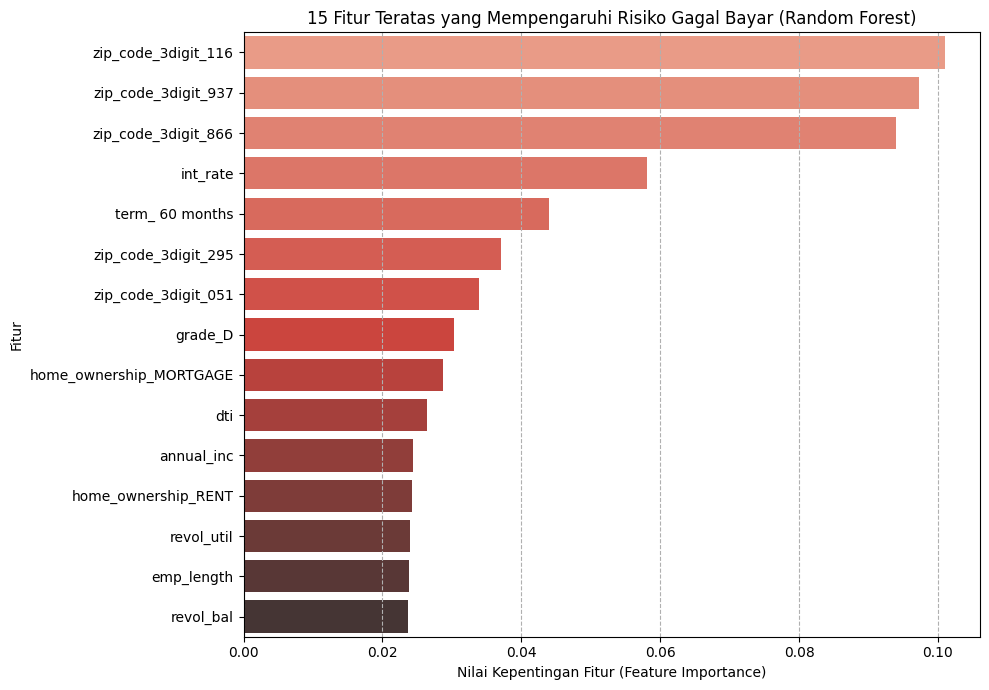

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rf_model = pipeline.named_steps['classifier']

feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)

top_15_features = feature_importances.nlargest(15)

print("=" * 50)
print("## 13. 15 Fitur Paling Berpengaruh Terhadap Risiko")
print("=" * 50)
display(top_15_features)
print("-" * 50)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_15_features.values, y=top_15_features.index, palette='Reds_d')
plt.title('15 Fitur Teratas yang Mempengaruhi Risiko Gagal Bayar (Random Forest)')
plt.xlabel('Nilai Kepentingan Fitur (Feature Importance)')
plt.ylabel('Fitur')
plt.grid(axis='x', linestyle='--')
plt.tight_layout()
plt.show()